In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Данные
x = np.array([-2, -1.5, -1, 0.5, 0, 0.5, 1, 1.5, 2, 2.5])
y = np.array([4.03, 2.83, 2.14, 1.26, 1.57, 0.28, 0.57, 0.16, 0.23, 0.48])

In [3]:
def new_iter(vars, J, F):
    return vars - np.linalg.inv(J) @ F

def F(vars):
    a, A = vars
    eq1 = np.round(np.sum(y * np.exp(a * x)) - A * np.sum(np.exp(2 * a * x)), 3)
    eq2 = np.round(np.sum(x * y * np.exp(a * x)) - A * np.sum(x * np.exp(2 * a * x)), 3)
    return np.round(np.array([eq1, eq2]), 3)

# Якобиан системы уравнений
def J(vars):
    a, A = vars
    # Частные производные по a
    dF1_da = np.sum(y * x * np.exp(a * x)) - A * 2 * np.sum(x * np.exp(2 * a * x))
    dF1_dA = -np.sum(np.exp(2 * a * x))
    dF2_da = np.sum(x * y * x * np.exp(a * x)) - A * 2 * np.sum(x**2 * np.exp(2 * a * x))
    dF2_dA = -np.sum(x * np.exp(2 * a * x))
    return np.round(np.array([[dF1_da, dF1_dA],
                     [dF2_da, dF2_dA]]), 3)

In [ ]:
# Таблица результатов
results = []

# Начальные значения
def start_values():
    alpha = 1 / (x[0] - x[-1]) * np.log(y[0] / y[-1])
    A = y[0] * (y[0] / y[-1]) ** (x[0] / (x[-1] - x[0])) 
    return alpha, A


start_values

In [28]:
import pandas as pd

def values(vars):
    a, A = vars
    u1k = np.exp(2 * a * x)
    v1k = A * x * np.exp(2 * a * x) 
    u2k = x * np.exp(2 * a * x)
    v2k = A * x**2 * np.exp(2 * a * x)
    z1k = np.exp(a * x) * (y - A * np.exp(a * x))
    z2k = x * np.exp(a * x) * (y - A * np.exp(a * x))
    return pd.DataFrame({
        "x": x, 
        "y": y, 
        "v_1k": v1k, 
        "v_2k": v2k, 
        "u_1k": u1k, 
        "u_2k": u2k, 
        "z_11": z1k, 
        "z_2k": z2k
    })

In [29]:
def print_cases(X, Y, i):
    text = "Система нормальный уравнений принимает вид  \\begin{equation*} \n" + \
    "\\begin{cases}\n" + \
    f"{X[0][0]}  \\Delta A^{{ ({i}) }}  +  {X[0][1]}  \\Delta \\alpha ^{{({i})}}= {Y[0]}; \\\\ \n" + \
     f" {X[1][0]} \\Delta A^{{({i})}}  + {X[1][1]}\\Delta \\alpha ^{{({i})}}  = {Y[1]};\n" + \
   " \end{cases}" + \
"\end{equation*},\n "
    
    return text

In [31]:
print(start_values())

(np.float64(-0.47283012245306494), np.float64(1.5653448185310241))


In [ ]:
vars = start_values()
for i in range(10): 
    df = values(vars)
    sum_df = np.round(df.sum(axis=0)[2:], 3)
    name = df.keys()
    df = pd.concat([df, pd.DataFrame(df[name[2:]].sum()).T]).fillna('')
    text_to_latex = df.to_latex(float_format="%.3f")
    text_to_latex = text_to_latex.replace("\\\n", "\\ \hline\n")
    text_to_latex = text_to_latex.replace("lllrrrrrr", "|l|r|r|r|r|r|r|r|r|")
    text_to_latex = text_to_latex.replace("& x & y & v_1k & v_2k & u_1k & u_2k & z_11 & z_2k", "k & x & y & $v_{1k}$ & $v_{2k}$ & $u_{1k}$ & $u_{2k}$ & $z_{1k}$ & $z_{2k}$")
    print(text_to_latex)
    
    a = np.round(np.array(
        [
            [sum_df[0], sum_df[2]], 
            [sum_df[1], sum_df[3]]
        ]), 3)
    b = np.round(np.array([
        [sum_df[4]], 
        [sum_df[5]]
        ]), 3)
    new_vars = np.round(np.linalg.solve(a, b).T, 3)
    print(print_cases(a, b, i))

    print(f"решением будет $\\Delta \\alpha^{{ (i)}}  = {new_vars[0][0]}; \\Delta A^{{({i})}} = {new_vars[0][1]} $ \\\\")
    vars += new_vars[0]
    vars = np.round(vars, 3)
    print(f"Получаем $\\alpha^{{({i})}} = {vars[0]}; A^{{({i})}} = {vars[1]}$")
    if np.max(np.abs(new_vars)) < 0.001:
        print("iteration:", i)
        break 

\begin{tabular}{|l|r|r|r|r|r|r|r|r|}
\toprule
 k & x & y & $v_{1k}$ & $v_{2k}$ & $u_{1k}$ & $u_{2k}$ & $z_{1k}$ & $z_{2k}$ \\ \hline
\midrule
0 & -2.000 & 4.030 & -20.751 & 41.501 & 6.628 & -13.256 & 0.000 & -0.000 \\ \hline
1 & -1.500 & 2.830 & -9.699 & 14.549 & 4.131 & -6.196 & -0.714 & 1.072 \\ \hline
2 & -1.000 & 2.140 & -4.030 & 4.030 & 2.575 & -2.575 & -0.596 & 0.596 \\ \hline
3 & 0.500 & 1.260 & 0.488 & 0.244 & 0.623 & 0.312 & 0.019 & 0.010 \\ \hline
4 & 0.000 & 1.570 & 0.000 & 0.000 & 1.000 & 0.000 & 0.005 & 0.000 \\ \hline
5 & 0.500 & 0.280 & 0.488 & 0.244 & 0.623 & 0.312 & -0.755 & -0.377 \\ \hline
6 & 1.000 & 0.570 & 0.608 & 0.608 & 0.388 & 0.388 & -0.253 & -0.253 \\ \hline
7 & 1.500 & 0.160 & 0.568 & 0.853 & 0.242 & 0.363 & -0.300 & -0.450 \\ \hline
8 & 2.000 & 0.230 & 0.472 & 0.945 & 0.151 & 0.302 & -0.147 & -0.294 \\ \hline
9 & 2.500 & 0.480 & 0.368 & 0.920 & 0.094 & 0.235 & 0.000 & 0.000 \\ \hline
0 &  &  & -31.488 & 63.893 & 16.455 & -20.115 & -2.741 & 0.303 \\ \hline
\

C:\Users\aveoc\AppData\Local\Temp\ipykernel_1284\3440841489.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[0], sum_df[2]],
C:\Users\aveoc\AppData\Local\Temp\ipykernel_1284\3440841489.py:16: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[1], sum_df[3]]
C:\Users\aveoc\AppData\Local\Temp\ipykernel_1284\3440841489.py:19: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  [sum_df[4]],
C:\Users\aveoc\AppData\Local\Temp\ipy

In [36]:
def y_pred(vars,):
    a, A = vars
    return np.round(A * np.exp(a * x), 3)



In [44]:
CAS = pd.DataFrame(
    {
        "$x_k$": x,
        "$y_k$": y,
        "$\\hat{y_k}$": y_pred(vars),
        "$y-\\hat{y_k}$": y-y_pred(vars),
        "$(y-\\hat{y_k})^2$": (y-y_pred(vars))**2,
        "$\\hat{y_k}^2$": y_pred(vars)**2
    }
)#check adequacy system

text_in_latex = CAS.to_latex(index=False, float_format="%.3f").replace("rrrrrr", "|c|c|c|c|c|c|")
text_in_latex = text_in_latex.replace("\\\n", "\\ \hline\n")

print(text_in_latex)

\begin{tabular}{|c|c|c|c|c|c|}
\toprule
$x_k$ & $y_k$ & $\hat{y_k}$ & $y-\hat{y_k}$ & $(y-\hat{y_k})^2$ & $\hat{y_k}^2$ \\ \hline
\midrule
-2.000 & 4.030 & 3.998 & 0.032 & 0.001 & 15.984 \\ \hline
-1.500 & 2.830 & 2.932 & -0.102 & 0.010 & 8.597 \\ \hline
-1.000 & 2.140 & 2.151 & -0.011 & 0.000 & 4.627 \\ \hline
0.500 & 1.260 & 0.849 & 0.411 & 0.169 & 0.721 \\ \hline
0.000 & 1.570 & 1.157 & 0.413 & 0.171 & 1.339 \\ \hline
0.500 & 0.280 & 0.849 & -0.569 & 0.324 & 0.721 \\ \hline
1.000 & 0.570 & 0.622 & -0.052 & 0.003 & 0.387 \\ \hline
1.500 & 0.160 & 0.456 & -0.296 & 0.088 & 0.208 \\ \hline
2.000 & 0.230 & 0.335 & -0.105 & 0.011 & 0.112 \\ \hline
2.500 & 0.480 & 0.246 & 0.234 & 0.055 & 0.061 \\ \hline
\bottomrule
\end{tabular}



In [48]:
Q_min = CAS["$(y-\\hat{y_k})^2$"].sum()
R = CAS["$\\hat{y_k}^2$"].sum()
print(Q_min, R)
print(Q_min**0.5 / R**0.5 * 100)

0.830901 32.755241000000005
15.927009578716794


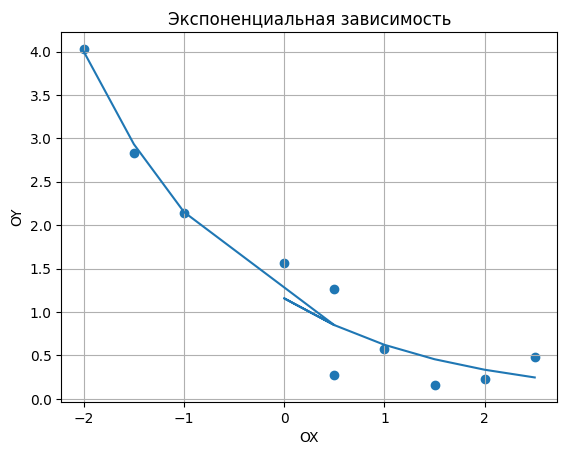

In [52]:
# строим график
plt.plot(x, y_pred(vars))
plt.scatter(x, y)
plt.grid()
plt.xlabel("OX")
plt.ylabel("OY")
plt.title("Экспоненциальная зависимость")
plt.show()